In [1]:
from pathlib import Path
import pandas as pd
from timesnet_encoder import TimesBlock
from sequences_peaks import SequenceConfig, _load_sequence_dataframe, _load_signal_from_row, _generate_peak_mask, TrainSequence, ValidationSequence
from dataclasses import replace
from utils import setup_gpu

setup_gpu(memory_fraction=1)


2026-04-09 09:56:39.699916: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-09 09:56:39.699948: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-09 09:56:39.700895: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-09 09:56:39.705651: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


gpouıoıraestodf
gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-04-09 09:56:42.500080: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 09:56:42.506141: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 09:56:42.507994: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:

DATA_FOLDER = Path("/tf/start_training/data/signal/2026-02-11-walking-with-peaks")

# CSV yolları (peaks sütunu içeren yeni dosyaların)
TRAIN_CSV = DATA_FOLDER / "train.csv"
VAL_CSV = DATA_FOLDER / "validation.csv"
TEST_CSV = DATA_FOLDER / "test.csv"

WINDOW_SIZE = 5000
LABEL_NAMES = ['walking']
# Sequence ayarları
config = SequenceConfig(
    csv_path=TRAIN_CSV,
    batch_size=32,
    n_classes=len(LABEL_NAMES), # Örn: 3 sınıf
    window_size=WINDOW_SIZE,
    shuffle=True,
    balance=True
)
train_seq = TrainSequence(config)
val_seq = ValidationSequence(replace(config, csv_path=VAL_CSV))

In [3]:
encoder = TimesBlock.build_encoder_v4()
generator = TimesBlock.build_generator_v4()
discriminator = TimesBlock.build_discriminator_v4()

encoder.summary()
generator.summary()
discriminator.summary()

2026-04-09 09:56:42.562370: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 09:56:42.564363: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 09:56:42.566078: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Model: "Encoder_V4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 signal_input_only (InputLa  [(None, 5000, 1)]         0         
 yer)                                                            
                                                                 
 conv1d (Conv1D)             (None, 625, 64)           2688      
                                                                 
 batch_normalization (Batch  (None, 625, 64)           256       
 Normalization)                                                  
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 625, 64)           0         
                                                                 
 times_block (TimesBlock)    (None, 625, 64)           74112     
                                                                 
 times_block_1 (TimesBlock)  (None, 625, 64)           7

In [4]:
import tensorflow as tf
# import tf_keras as keras
classifier = tf.keras.models.load_model("/tf/models/clf939.h5")
classifier.trainable = False
WALKING_INDEX = 6

In [5]:
def prepare_for_classifier(fake_signals):
    # 1. Kanal boyutunu kaldır: (Batch, 5000, 1) -> (Batch, 5000)
    s = tf.squeeze(fake_signals, axis=-1)
    # [1, 4] -> Batch boyutunu 1 kez, zaman boyutunu 4 kez tekrarla
    s_20k = tf.tile(s, [1, 4])
    
    return s_20k

In [6]:
# Optimizer'lar
enc_gen_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, clipnorm=1.0)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, clipnorm=1.0)

# Kayıp fonksiyonları
bce = tf.keras.losses.BinaryCrossentropy()
mse = tf.keras.losses.MeanSquaredError()

# coefficients

alpha = 1.0 
beta = 0.5

In [7]:
@tf.function
def train_step(real_signals, peak_masks):
    batch_size = tf.shape(real_signals)[0]
    WALKING_INDEX = 6
    
    # -------------------------------------------------------------
    # KRİTİK EKLENTİ: Gerçek sinyalleri [-1, 1] aralığına normalize et
    # -------------------------------------------------------------
    # Sinyalin batch içindeki min ve max değerlerini bul
    s_min = tf.reduce_min(real_signals, axis=[1, 2], keepdims=True)
    s_max = tf.reduce_max(real_signals, axis=[1, 2], keepdims=True)
    
    # Önce 0 ile 1 arasına çek
    s_norm = (real_signals - s_min) / (s_max - s_min + 1e-8) 
    # Sonra -1 ile 1 arasına çek (tanh formatı)
    real_signals_normalized = (s_norm * 2.0) - 1.0
    # -------------------------------------------------------------

    # --- DISCRIMINATOR EĞİTİMİ ---
    with tf.GradientTape() as disc_tape:
        # Artık modele normalize edilmiş veriyi veriyoruz
        z = encoder(real_signals_normalized, training=False)
        fake_signals = generator([z, peak_masks], training=False)
        
        pred_real = discriminator(real_signals_normalized, training=True)
        pred_fake = discriminator(fake_signals, training=True)
        
        d_loss = bce(tf.ones_like(pred_real), pred_real) + \
                 bce(tf.zeros_like(pred_fake), pred_fake)

    grads_disc = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    disc_optimizer.apply_gradients(zip(grads_disc, discriminator.trainable_variables))

    # --- ENCODER & GENERATOR EĞİTİMİ ---
    with tf.GradientTape() as gen_tape:
        z = encoder(real_signals_normalized, training=True)
        fake_signals = generator([z, peak_masks], training=True)
        
        # 1. L_rec (Adversarial + MSE)
        pred_fake_disc = discriminator(fake_signals, training=False)
        l_adv = bce(tf.ones_like(pred_fake_disc), pred_fake_disc)
        
        # DİKKAT: MSE'yi de normalize edilmiş veriyle ölçüyoruz!
        l_mse = mse(real_signals_normalized, fake_signals)
        L_rec = l_adv + (10.0 * l_mse)
        
        # 2. L_cls (Classifier Onayı)
        # prepare_for_classifier içindeki (x+1)/2 işlemi fake_signals'ı
        # Classifier'ın beklediği 0-1 aralığına çevirecek.
        fake_20k = prepare_for_classifier(fake_signals) 
        cls_predictions = classifier(fake_20k, training=False)
        
        walking_scores = cls_predictions[:, WALKING_INDEX]
        L_cls = bce(tf.ones((batch_size,)), walking_scores)
        
        # Toplam Loss
        total_gen_loss = (alpha * L_rec) + (beta * L_cls)

    var_list = encoder.trainable_variables + generator.trainable_variables
    grads_gen = gen_tape.gradient(total_gen_loss, var_list)
    enc_gen_optimizer.apply_gradients(zip(grads_gen, var_list))
    
    return d_loss, total_gen_loss, L_rec, L_cls

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_epoch_results(epoch, encoder, generator, train_seq):
    # 1. Eğitim setinden rastgele bir batch al
    batch_idx = np.random.randint(0, len(train_seq))
    batch_data, _ = train_seq[batch_idx]
    
    # 2. Gerçek verileri ayır (Sadece ilk örneği görselleştirelim)
    real_sig = batch_data[0:1, :, 0:1] # (1, 5000, 1)
    peak_mask = batch_data[0:1, :, 1:2] # (1, 5000, 1) - Bu bizim "Condition"ımız
    
    # 3. Modelden üretim yap
    # Encoder sinyali anlar, Generator peak maskesini kullanarak yeniden çizer
    embedding = encoder(real_sig, training=False)
    fake_sig = generator([embedding, peak_mask], training=False)
    
    # 4. Görselleştirme
    plt.figure(figsize=(18, 10))
    
    # Üst Panel: Gerçek Sinyal ve Peak Maskesi
    plt.subplot(2, 1, 1)
    plt.plot(real_sig[0, :, 0], color='gray', alpha=0.6, label='Orijinal DAS Sinyali (Ground Truth)')
    plt.fill_between(range(5000), peak_mask[0, :, 0] * np.max(real_sig), 
                     color='red', alpha=0.2, label='Gerçek Peak Iskeleti (Input to Gen)')
    plt.title(f"Epoch {epoch+1}: Orijinal Veri ve Peak Referansı")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    # Alt Panel: Üretilen Sinyal ve Aynı Peak Maskesi
    plt.subplot(2, 1, 2)
    plt.plot(fake_sig[0, :, 0], color='dodgerblue', linewidth=1.2, label='AI Tarafından Üretilen Sinyal')
    plt.fill_between(range(5000), peak_mask[0, :, 0] * np.max(fake_sig), 
                     color='red', alpha=0.2, label='Aynı Peak Iskeleti (Reconstruction)')
    plt.title(f"Epoch {epoch+1}: Jeneratörün Peak'lere Göre Çizdiği Sinyal")
    plt.xlabel("Sample Index (5000)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


--- EPOCH 1 BAŞLADI ---
Veri setinden ilk batch çekiliyor...

[BİLGİ] İlk step train_step'e gönderildi. TensorFlow grafiği derliyor (Tracing).
Bu işlem sistemine bağlı olarak 1-5 dakika sürebilir. Lütfen bekleyin...



2026-04-09 09:57:26.677535: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-04-09 09:57:28.284420: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f0b914fb0b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-09 09:57:28.284441: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-09 09:57:28.287939: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775728648.340042   21489 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 1 | Step 366/367 | D_Loss: 0.7235 | G_Total: 4.65
Epoch 1 Özet | D_Loss: 0.6665 | G_Total: 5.75 | Rec: 1.88 | Cls: 5.54
--- EPOCH 2 BAŞLADI ---
Epoch 2 | Step 366/367 | D_Loss: 1.4254 | G_Total: 2.57
Epoch 2 Özet | D_Loss: 1.2492 | G_Total: 2.58 | Rec: 1.86 | Cls: 1.42
--- EPOCH 3 BAŞLADI ---
Epoch 3 | Step 366/367 | D_Loss: 1.4203 | G_Total: 2.00
Epoch 3 Özet | D_Loss: 1.3981 | G_Total: 1.98 | Rec: 1.63 | Cls: 0.73
--- EPOCH 4 BAŞLADI ---
Epoch 4 | Step 366/367 | D_Loss: 1.3744 | G_Total: 1.61
Epoch 4 Özet | D_Loss: 1.4071 | G_Total: 1.55 | Rec: 1.61 | Cls: 0.00
--- EPOCH 5 BAŞLADI ---
Epoch 5 | Step 366/367 | D_Loss: 1.3878 | G_Total: 1.52
Epoch 5 Özet | D_Loss: 1.3775 | G_Total: 1.46 | Rec: 1.52 | Cls: 0.00


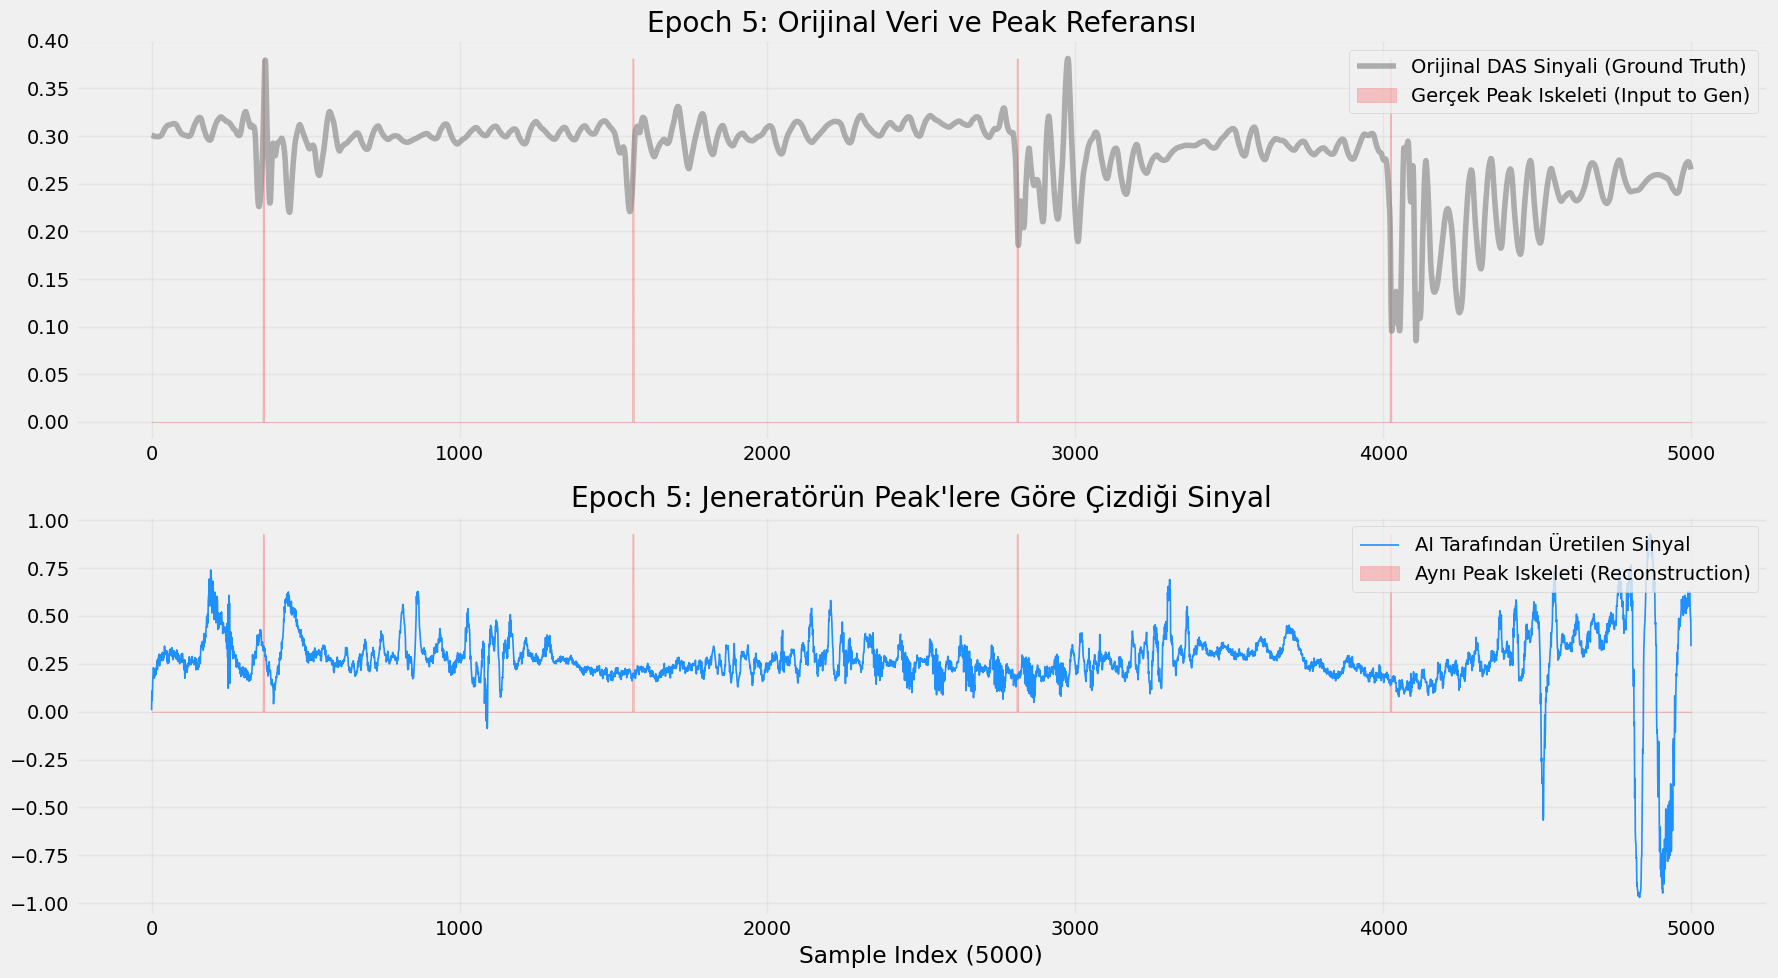

--- EPOCH 6 BAŞLADI ---
Epoch 6 | Step 366/367 | D_Loss: 1.3791 | G_Total: 1.44
Epoch 6 Özet | D_Loss: 1.3739 | G_Total: 1.43 | Rec: 1.44 | Cls: 0.00
--- EPOCH 7 BAŞLADI ---
Epoch 7 | Step 366/367 | D_Loss: 1.3263 | G_Total: 1.43
Epoch 7 Özet | D_Loss: 1.3690 | G_Total: 1.40 | Rec: 1.43 | Cls: 0.00
--- EPOCH 8 BAŞLADI ---
Epoch 8 | Step 366/367 | D_Loss: 1.3901 | G_Total: 1.37
Epoch 8 Özet | D_Loss: 1.3764 | G_Total: 1.39 | Rec: 1.37 | Cls: 0.00
--- EPOCH 9 BAŞLADI ---
Epoch 9 | Step 366/367 | D_Loss: 1.4199 | G_Total: 1.33
Epoch 9 Özet | D_Loss: 1.3700 | G_Total: 1.37 | Rec: 1.33 | Cls: 0.00
--- EPOCH 10 BAŞLADI ---
Epoch 10 | Step 366/367 | D_Loss: 1.3574 | G_Total: 1.34
Epoch 10 Özet | D_Loss: 1.3736 | G_Total: 1.35 | Rec: 1.34 | Cls: 0.00


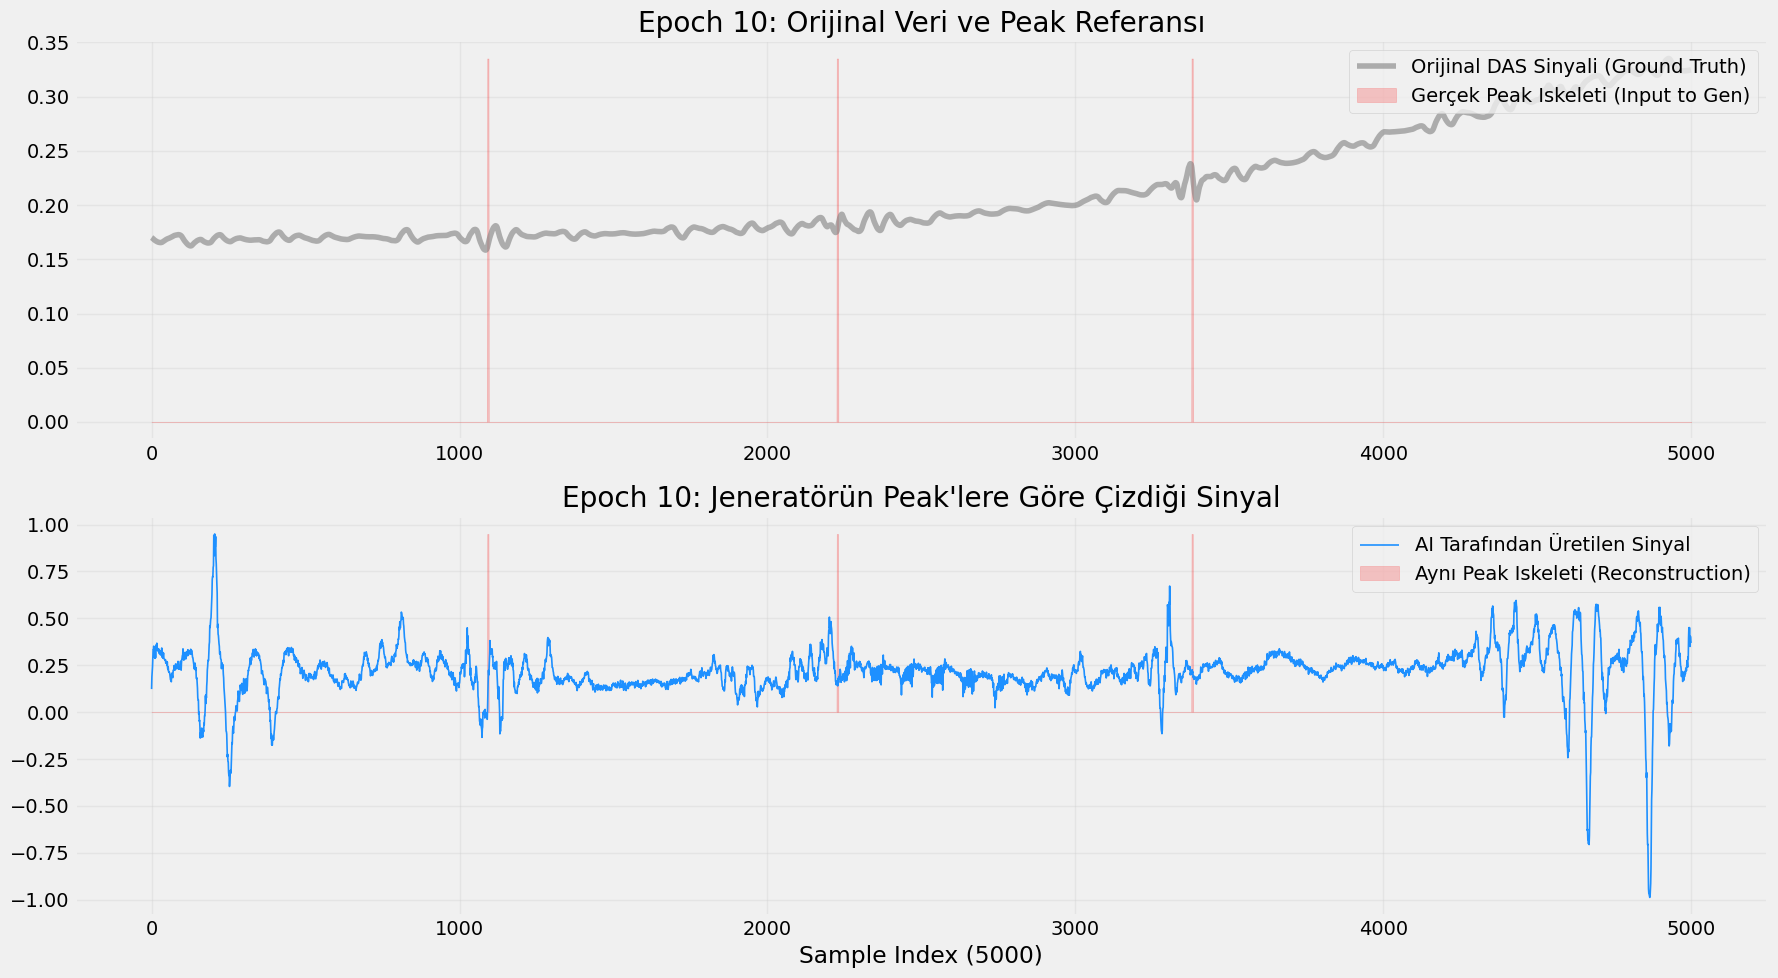

--- EPOCH 11 BAŞLADI ---
Epoch 11 | Step 366/367 | D_Loss: 1.3955 | G_Total: 1.32
Epoch 11 Özet | D_Loss: 1.3721 | G_Total: 1.33 | Rec: 1.32 | Cls: 0.00
--- EPOCH 12 BAŞLADI ---
Epoch 12 | Step 366/367 | D_Loss: 1.3545 | G_Total: 1.36
Epoch 12 Özet | D_Loss: 1.3658 | G_Total: 1.32 | Rec: 1.36 | Cls: 0.00
--- EPOCH 13 BAŞLADI ---
Epoch 13 | Step 366/367 | D_Loss: 1.4061 | G_Total: 1.33
Epoch 13 Özet | D_Loss: 1.3661 | G_Total: 1.32 | Rec: 1.33 | Cls: 0.00
--- EPOCH 14 BAŞLADI ---
Epoch 14 | Step 366/367 | D_Loss: 1.3657 | G_Total: 1.29
Epoch 14 Özet | D_Loss: 1.3728 | G_Total: 1.30 | Rec: 1.29 | Cls: 0.00
--- EPOCH 15 BAŞLADI ---
Epoch 15 | Step 366/367 | D_Loss: 1.3809 | G_Total: 1.29
Epoch 15 Özet | D_Loss: 1.3619 | G_Total: 1.31 | Rec: 1.29 | Cls: -0.00


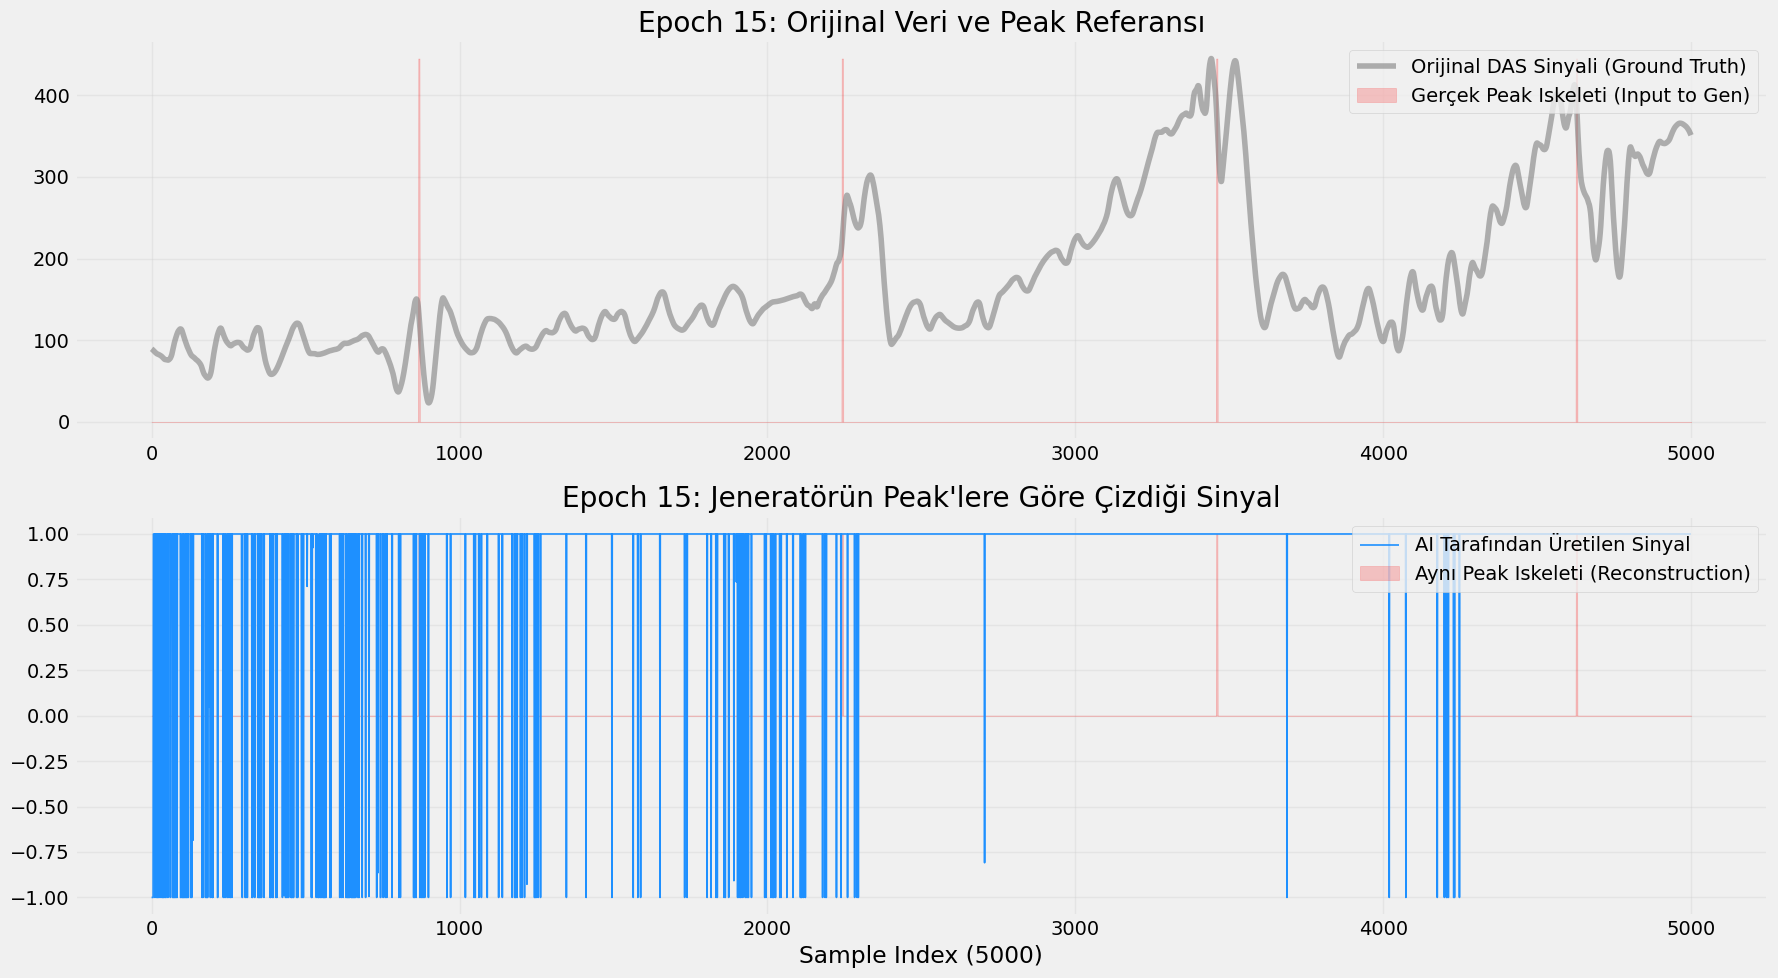

--- EPOCH 16 BAŞLADI ---
Epoch 16 | Step 366/367 | D_Loss: 1.4018 | G_Total: 1.28
Epoch 16 Özet | D_Loss: 1.3666 | G_Total: 1.31 | Rec: 1.28 | Cls: 0.00
--- EPOCH 17 BAŞLADI ---
Epoch 17 | Step 366/367 | D_Loss: 1.3890 | G_Total: 1.29
Epoch 17 Özet | D_Loss: 1.3669 | G_Total: 1.31 | Rec: 1.29 | Cls: 0.00
--- EPOCH 18 BAŞLADI ---
Epoch 18 | Step 366/367 | D_Loss: 1.3568 | G_Total: 1.28
Epoch 18 Özet | D_Loss: 1.3693 | G_Total: 1.29 | Rec: 1.28 | Cls: 0.00
--- EPOCH 19 BAŞLADI ---
Epoch 19 | Step 366/367 | D_Loss: 1.4192 | G_Total: 1.30
Epoch 19 Özet | D_Loss: 1.3667 | G_Total: 1.31 | Rec: 1.30 | Cls: 0.00
--- EPOCH 20 BAŞLADI ---
Epoch 20 | Step 366/367 | D_Loss: 1.3620 | G_Total: 1.33
Epoch 20 Özet | D_Loss: 1.3633 | G_Total: 1.29 | Rec: 1.33 | Cls: -0.00


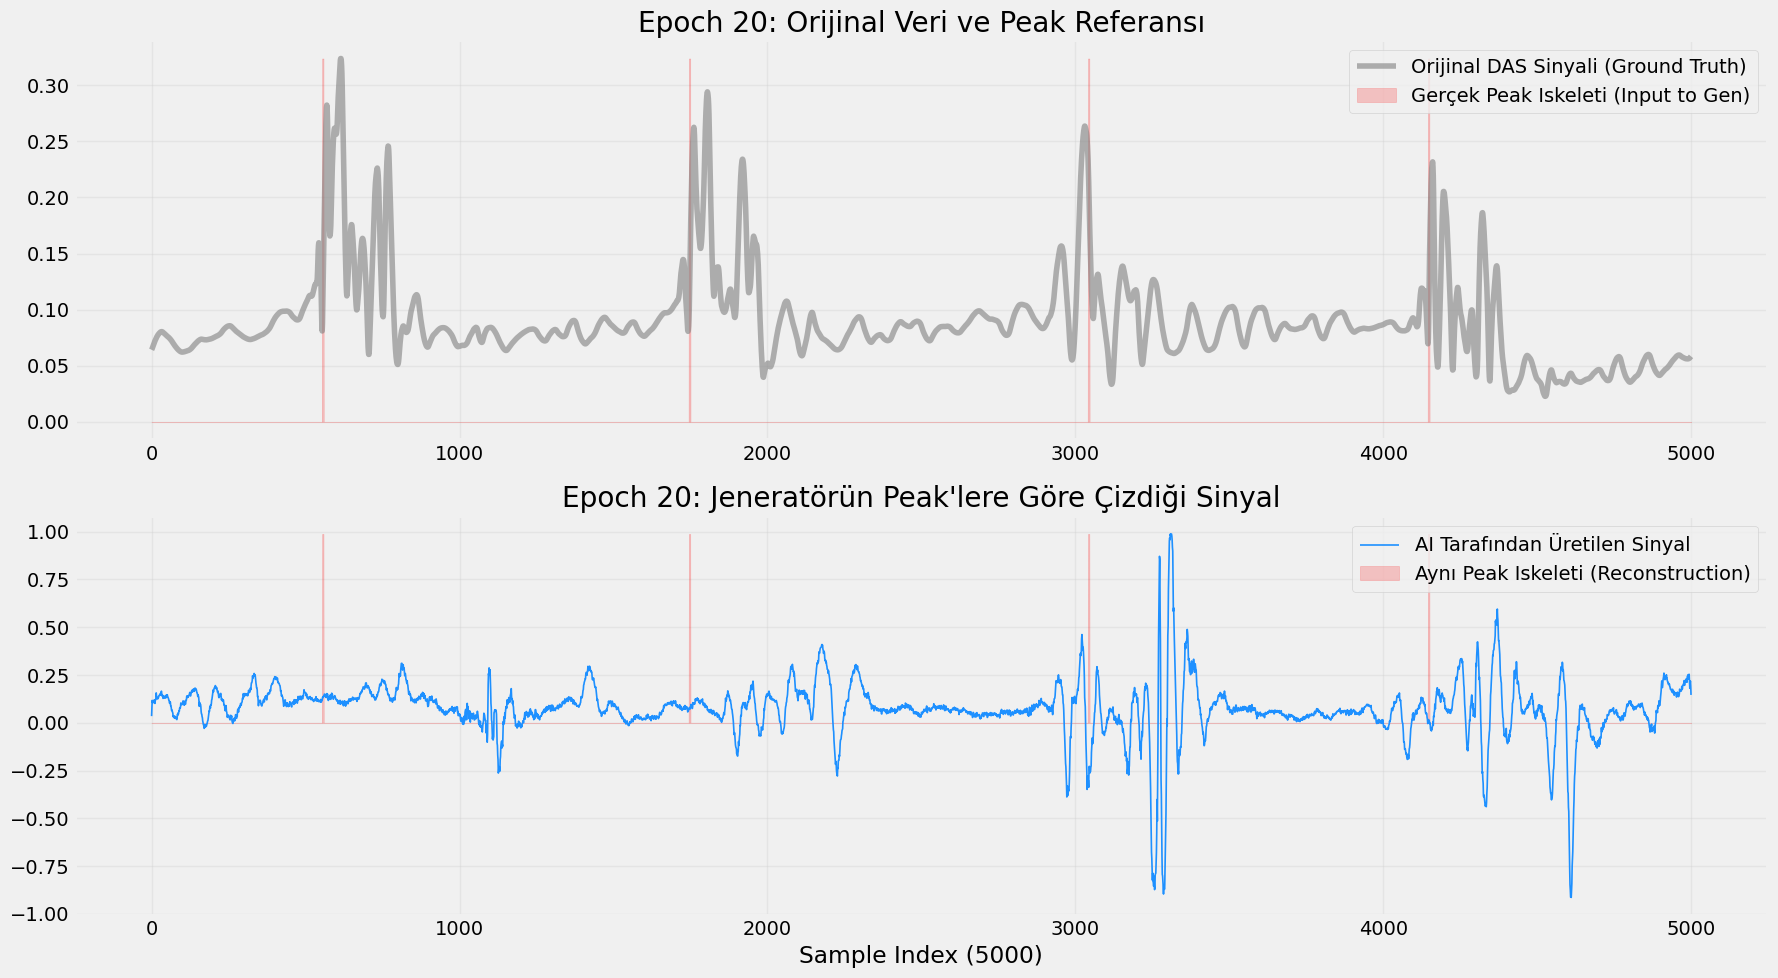

--- EPOCH 21 BAŞLADI ---
Epoch 21 | Step 366/367 | D_Loss: 1.4306 | G_Total: 1.31
Epoch 21 Özet | D_Loss: 1.3633 | G_Total: 1.29 | Rec: 1.31 | Cls: 0.00
--- EPOCH 22 BAŞLADI ---
Epoch 22 | Step 366/367 | D_Loss: 1.3407 | G_Total: 1.33
Epoch 22 Özet | D_Loss: 1.3565 | G_Total: 1.31 | Rec: 1.33 | Cls: 0.00
--- EPOCH 23 BAŞLADI ---
Epoch 23 | Step 366/367 | D_Loss: 1.3706 | G_Total: 1.28
Epoch 23 Özet | D_Loss: 1.3603 | G_Total: 1.29 | Rec: 1.28 | Cls: -0.00
--- EPOCH 24 BAŞLADI ---
Epoch 24 | Step 366/367 | D_Loss: 1.3811 | G_Total: 1.45
Epoch 24 Özet | D_Loss: 1.3614 | G_Total: 1.28 | Rec: 1.26 | Cls: 0.38
--- EPOCH 25 BAŞLADI ---
Epoch 25 | Step 366/367 | D_Loss: 1.3536 | G_Total: 1.31
Epoch 25 Özet | D_Loss: 1.3571 | G_Total: 1.28 | Rec: 1.31 | Cls: 0.00


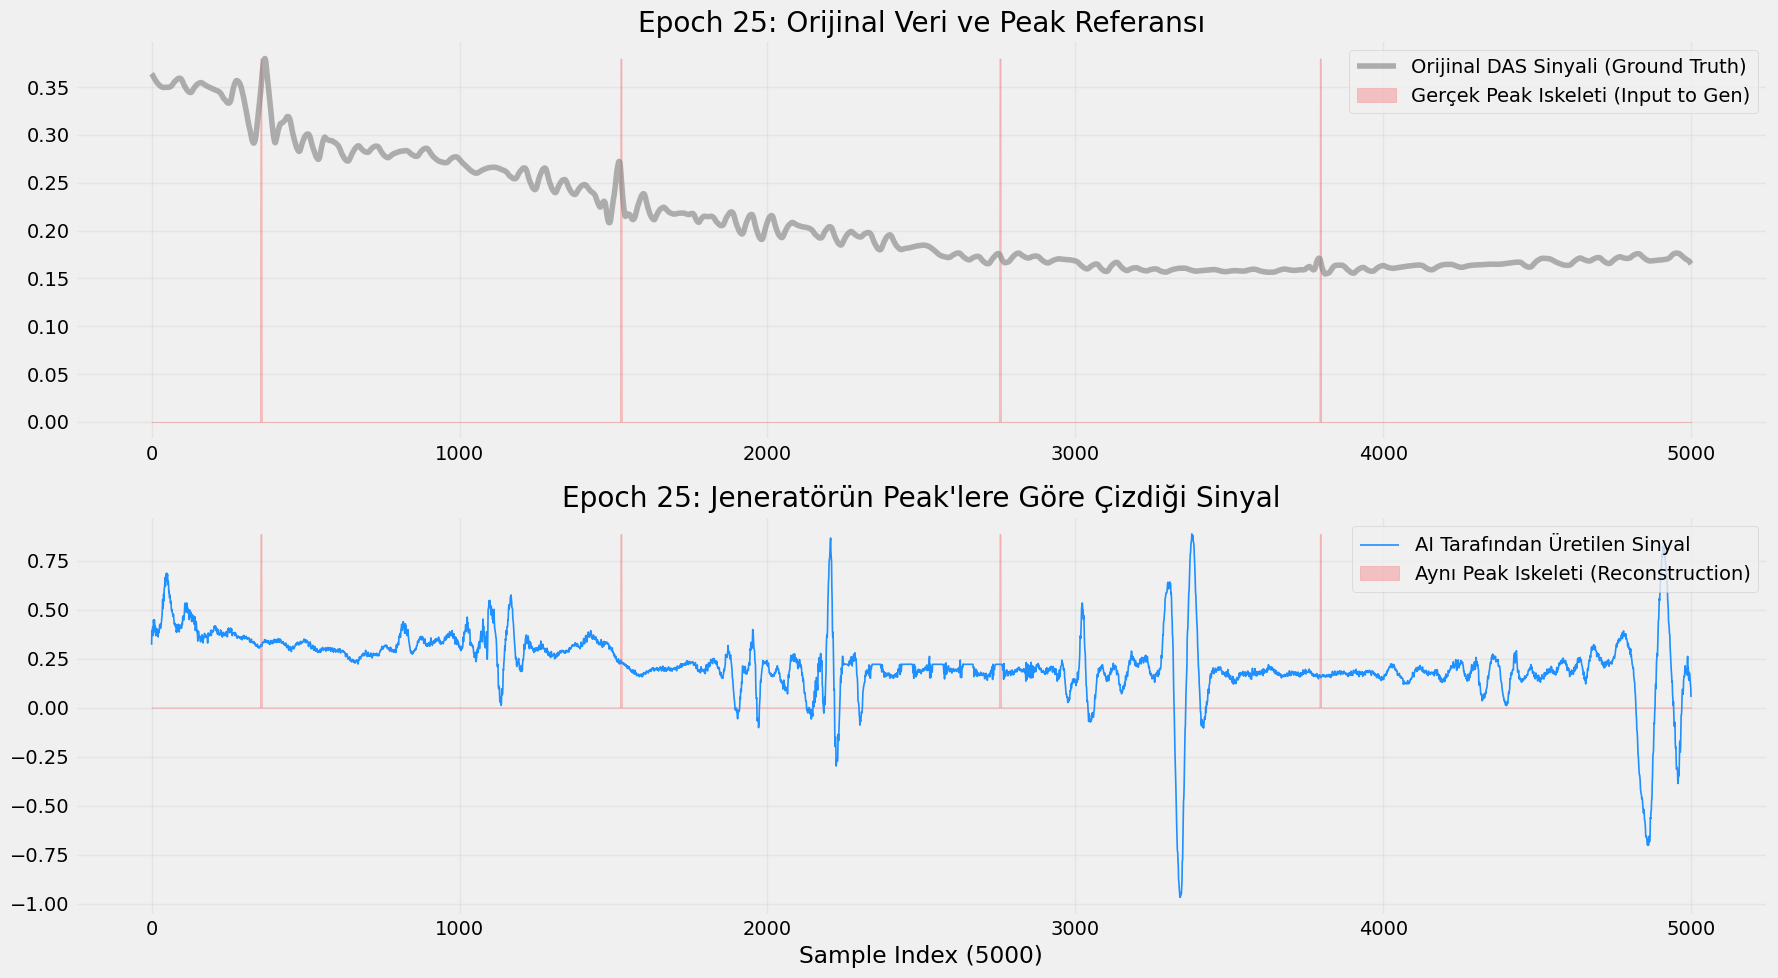

--- EPOCH 26 BAŞLADI ---
Epoch 26 | Step 366/367 | D_Loss: 1.3861 | G_Total: 1.26
Epoch 26 Özet | D_Loss: 1.3630 | G_Total: 1.27 | Rec: 1.26 | Cls: -0.00
--- EPOCH 27 BAŞLADI ---
Epoch 27 | Step 366/367 | D_Loss: 1.4245 | G_Total: 1.33
Epoch 27 Özet | D_Loss: 1.3487 | G_Total: 1.29 | Rec: 1.32 | Cls: 0.00
--- EPOCH 28 BAŞLADI ---
Epoch 28 | Step 366/367 | D_Loss: 1.3291 | G_Total: 1.30
Epoch 28 Özet | D_Loss: 1.3579 | G_Total: 1.28 | Rec: 1.30 | Cls: 0.00
--- EPOCH 29 BAŞLADI ---
Epoch 29 | Step 366/367 | D_Loss: 1.3614 | G_Total: 1.32
Epoch 29 Özet | D_Loss: 1.3649 | G_Total: 1.28 | Rec: 1.32 | Cls: 0.00
--- EPOCH 30 BAŞLADI ---
Epoch 30 | Step 366/367 | D_Loss: 1.3153 | G_Total: 1.31
Epoch 30 Özet | D_Loss: 1.3528 | G_Total: 1.29 | Rec: 1.31 | Cls: 0.00


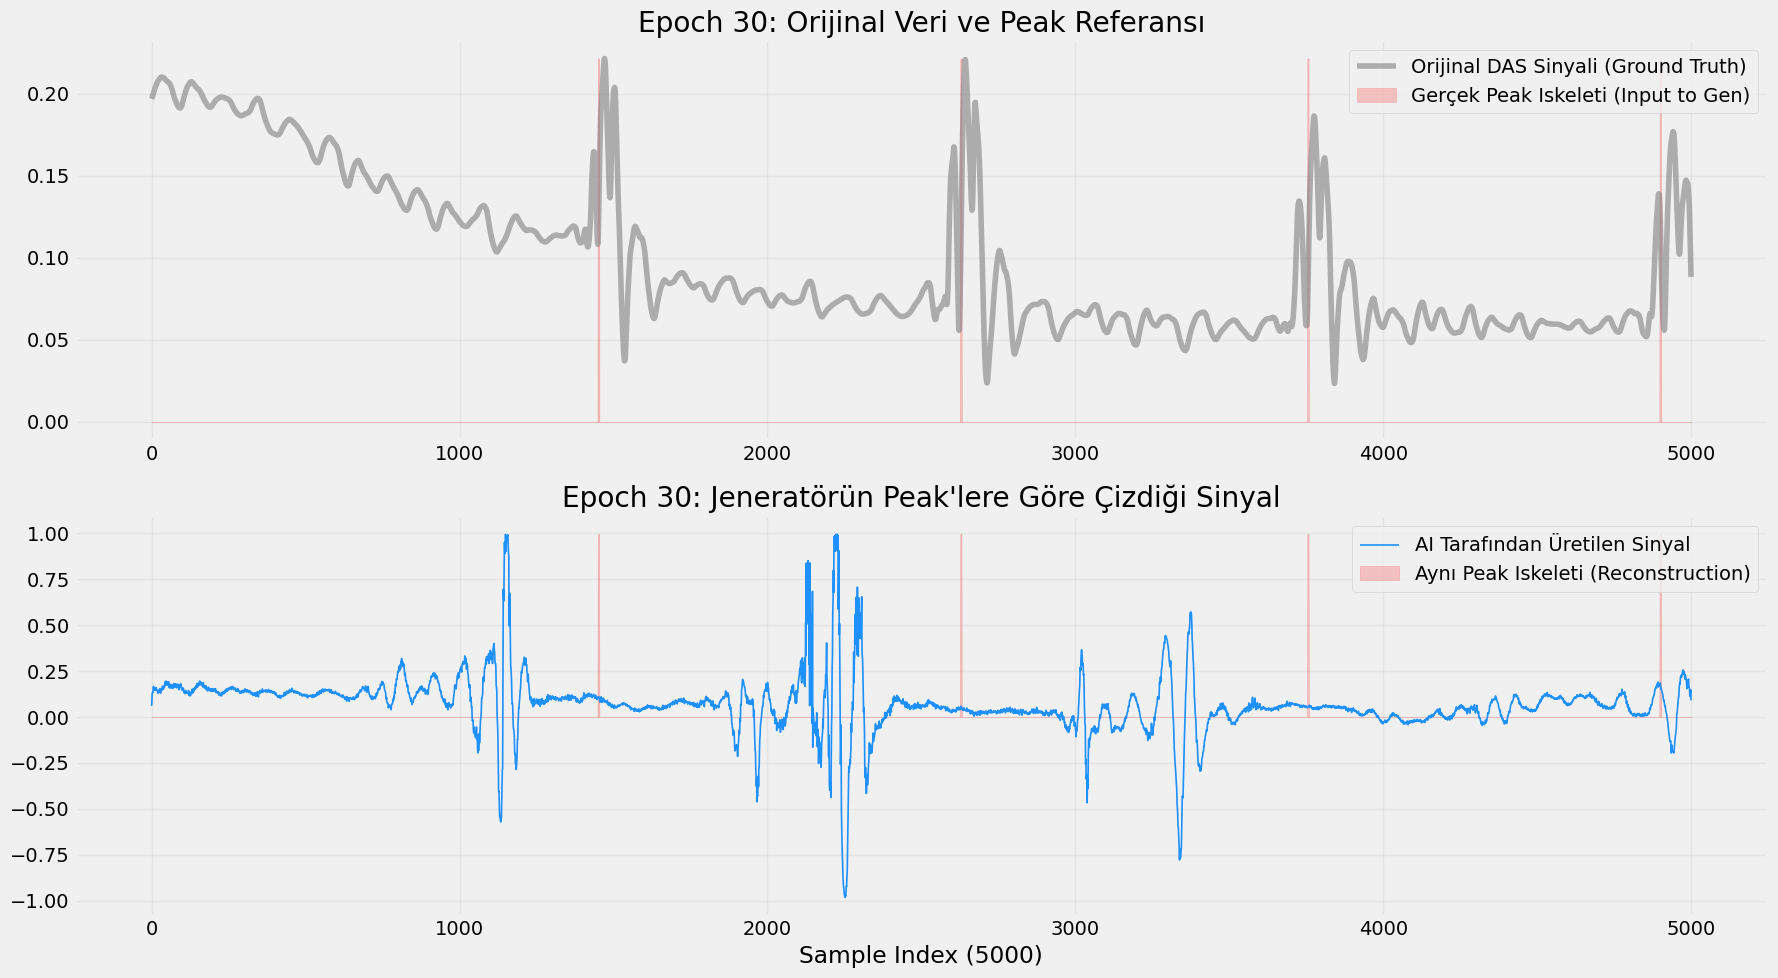

--- EPOCH 31 BAŞLADI ---
Epoch 31 | Step 366/367 | D_Loss: 1.3184 | G_Total: 1.31
Epoch 31 Özet | D_Loss: 1.3619 | G_Total: 1.26 | Rec: 1.31 | Cls: -0.00
--- EPOCH 32 BAŞLADI ---
Epoch 32 | Step 366/367 | D_Loss: 1.3037 | G_Total: 1.68
Epoch 32 Özet | D_Loss: 1.3604 | G_Total: 1.31 | Rec: 1.31 | Cls: 0.73
--- EPOCH 33 BAŞLADI ---
Epoch 33 | Step 366/367 | D_Loss: 1.3837 | G_Total: 1.29
Epoch 33 Özet | D_Loss: 1.3478 | G_Total: 1.30 | Rec: 1.29 | Cls: 0.00
--- EPOCH 34 BAŞLADI ---
Epoch 34 | Step 366/367 | D_Loss: 1.3581 | G_Total: 1.29
Epoch 34 Özet | D_Loss: 1.3580 | G_Total: 1.28 | Rec: 1.29 | Cls: 0.00
--- EPOCH 35 BAŞLADI ---
Epoch 35 | Step 366/367 | D_Loss: 1.2854 | G_Total: 1.29
Epoch 35 Özet | D_Loss: 1.3582 | G_Total: 1.28 | Rec: 1.29 | Cls: -0.00


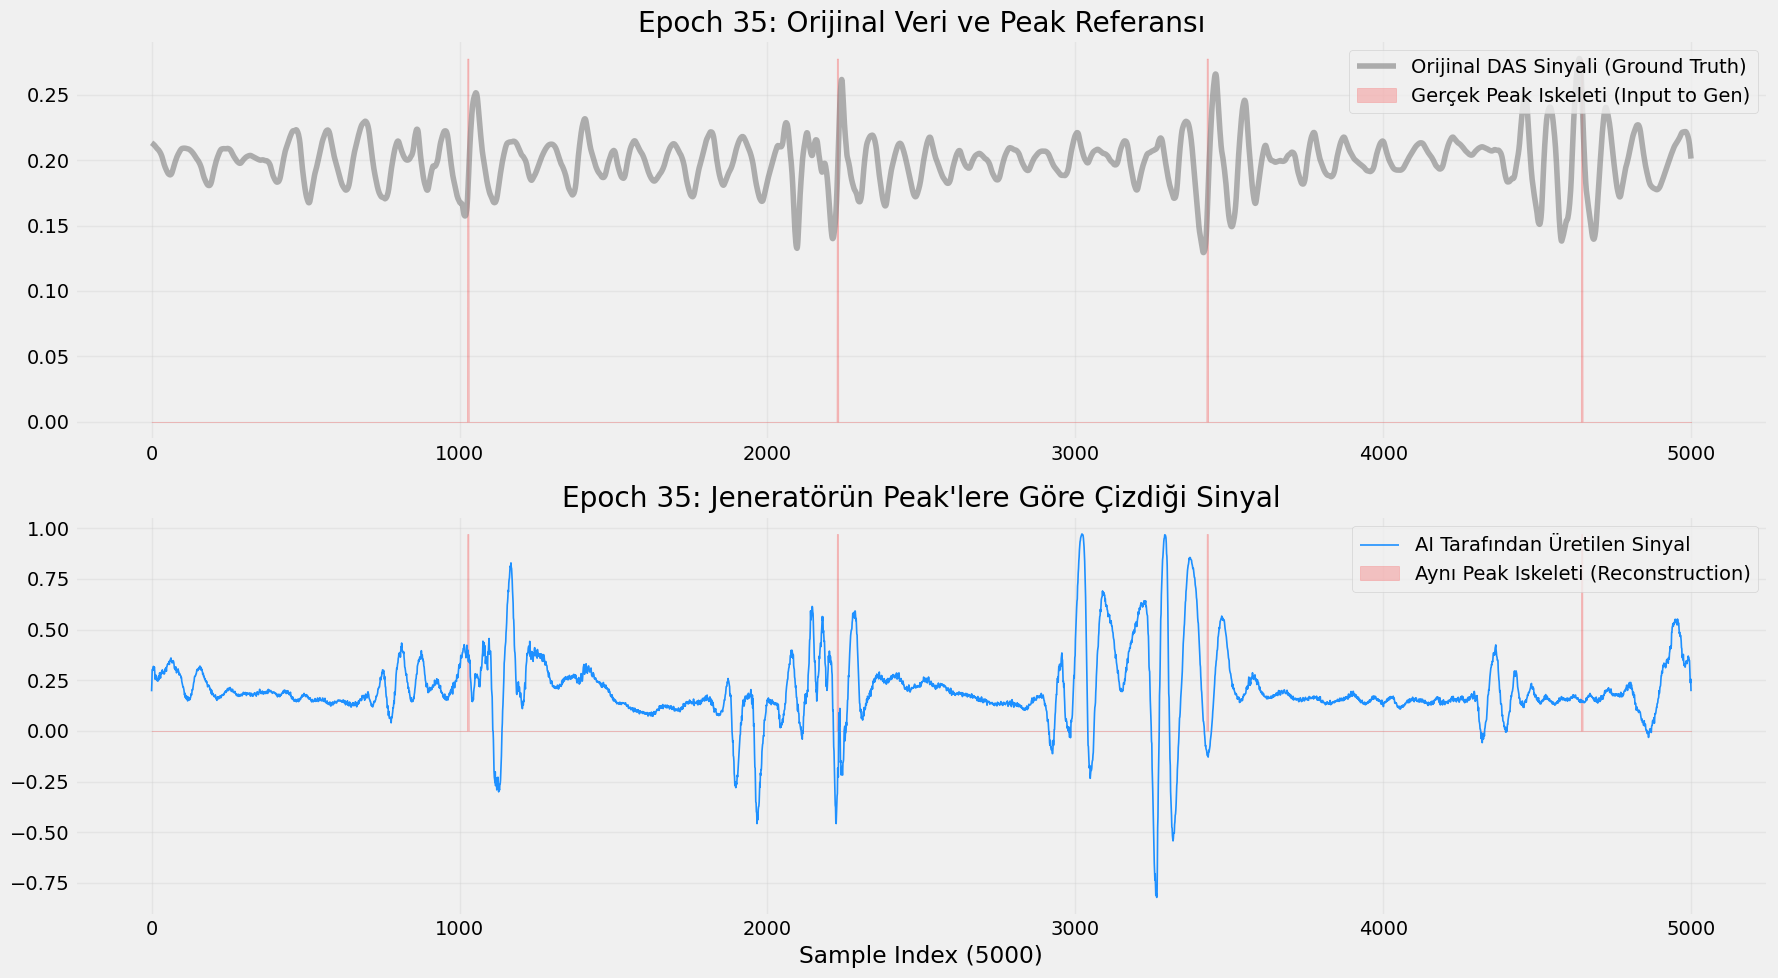

--- EPOCH 36 BAŞLADI ---
Epoch 36 | Step 366/367 | D_Loss: 1.3553 | G_Total: 1.32
Epoch 36 Özet | D_Loss: 1.3461 | G_Total: 1.30 | Rec: 1.32 | Cls: 0.00
--- EPOCH 37 BAŞLADI ---
Epoch 37 | Step 366/367 | D_Loss: 1.3497 | G_Total: 1.31
Epoch 37 Özet | D_Loss: 1.3565 | G_Total: 1.28 | Rec: 1.31 | Cls: 0.00
--- EPOCH 38 BAŞLADI ---
Epoch 38 | Step 366/367 | D_Loss: 1.2683 | G_Total: 1.40
Epoch 38 Özet | D_Loss: 1.3490 | G_Total: 1.27 | Rec: 1.39 | Cls: 0.01
--- EPOCH 39 BAŞLADI ---
Epoch 39 | Step 366/367 | D_Loss: 1.2631 | G_Total: 1.33
Epoch 39 Özet | D_Loss: 1.3515 | G_Total: 1.29 | Rec: 1.33 | Cls: 0.00
--- EPOCH 40 BAŞLADI ---
Epoch 40 | Step 366/367 | D_Loss: 1.3320 | G_Total: 1.35
Epoch 40 Özet | D_Loss: 1.3511 | G_Total: 1.29 | Rec: 1.35 | Cls: 0.00


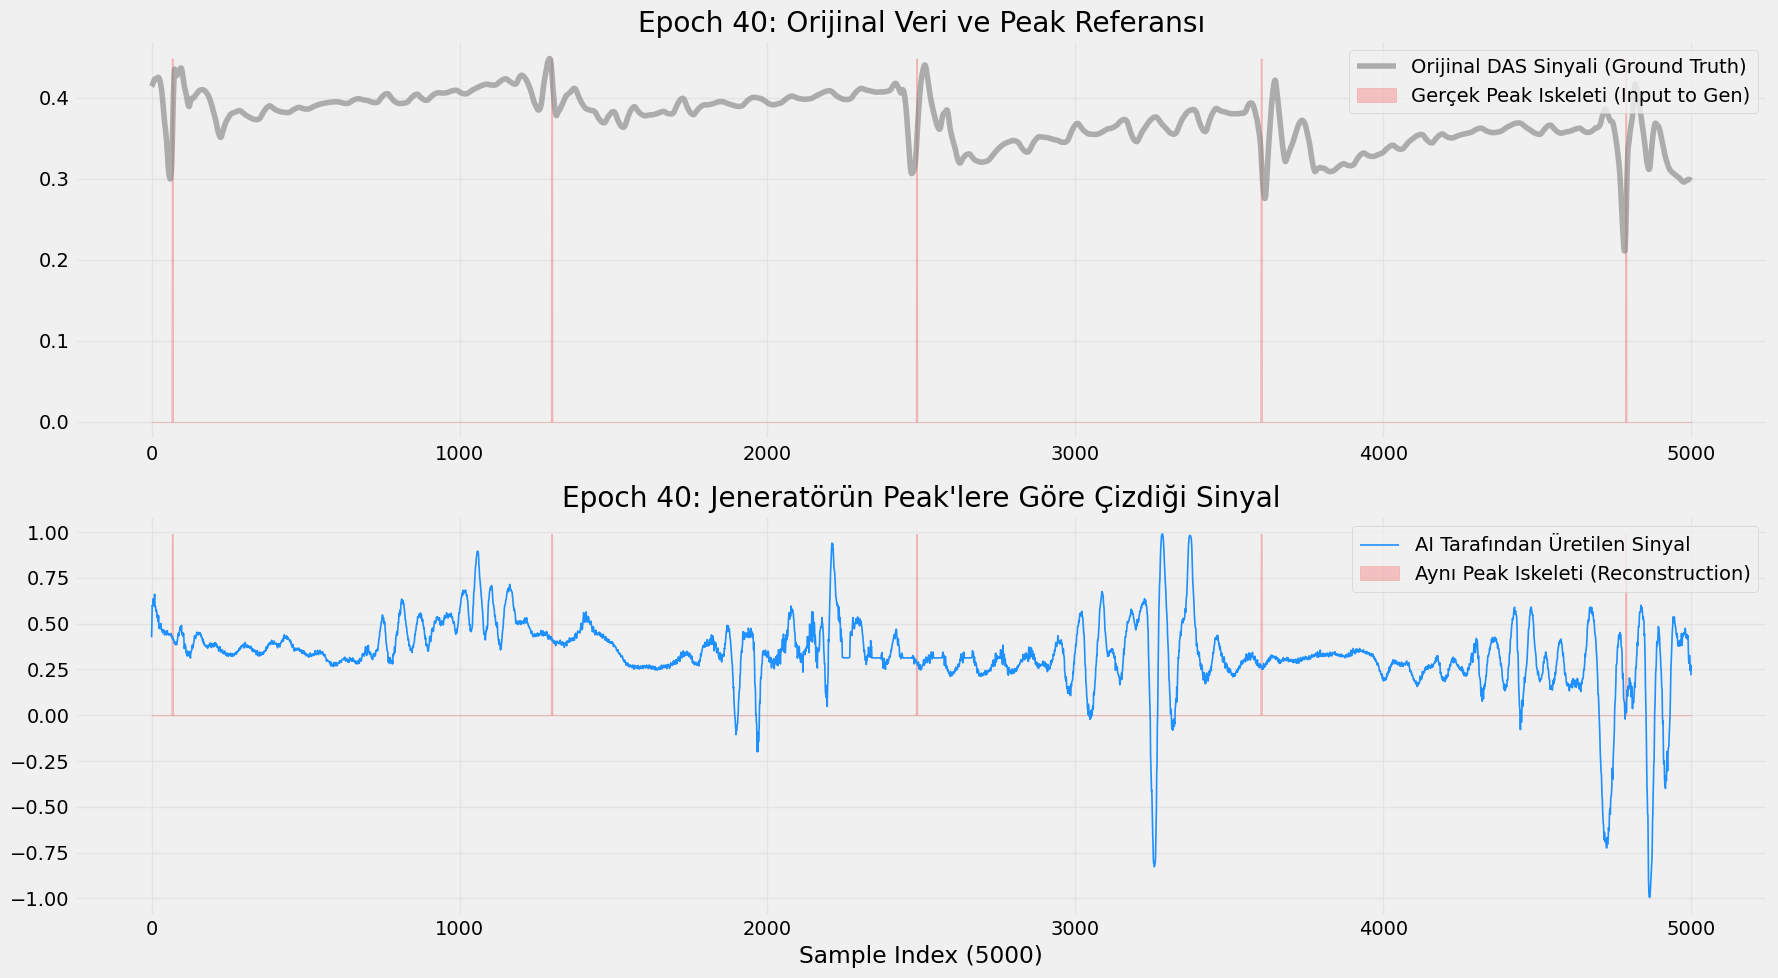

--- EPOCH 41 BAŞLADI ---
Epoch 41 | Step 366/367 | D_Loss: 1.3484 | G_Total: 1.26
Epoch 41 Özet | D_Loss: 1.3649 | G_Total: 1.26 | Rec: 1.26 | Cls: 0.00
--- EPOCH 42 BAŞLADI ---
Epoch 42 | Step 366/367 | D_Loss: 1.3332 | G_Total: 1.32
Epoch 42 Özet | D_Loss: 1.3623 | G_Total: 1.27 | Rec: 1.32 | Cls: 0.00
--- EPOCH 43 BAŞLADI ---
Epoch 43 | Step 366/367 | D_Loss: 1.3191 | G_Total: 1.31
Epoch 43 Özet | D_Loss: 1.3638 | G_Total: 1.27 | Rec: 1.31 | Cls: -0.00
--- EPOCH 44 BAŞLADI ---
Epoch 44 | Step 366/367 | D_Loss: 1.3851 | G_Total: 1.32
Epoch 44 Özet | D_Loss: 1.3566 | G_Total: 1.27 | Rec: 1.32 | Cls: 0.00
--- EPOCH 45 BAŞLADI ---
Epoch 45 | Step 366/367 | D_Loss: 1.3627 | G_Total: 1.33
Epoch 45 Özet | D_Loss: 1.3622 | G_Total: 1.26 | Rec: 1.33 | Cls: 0.00


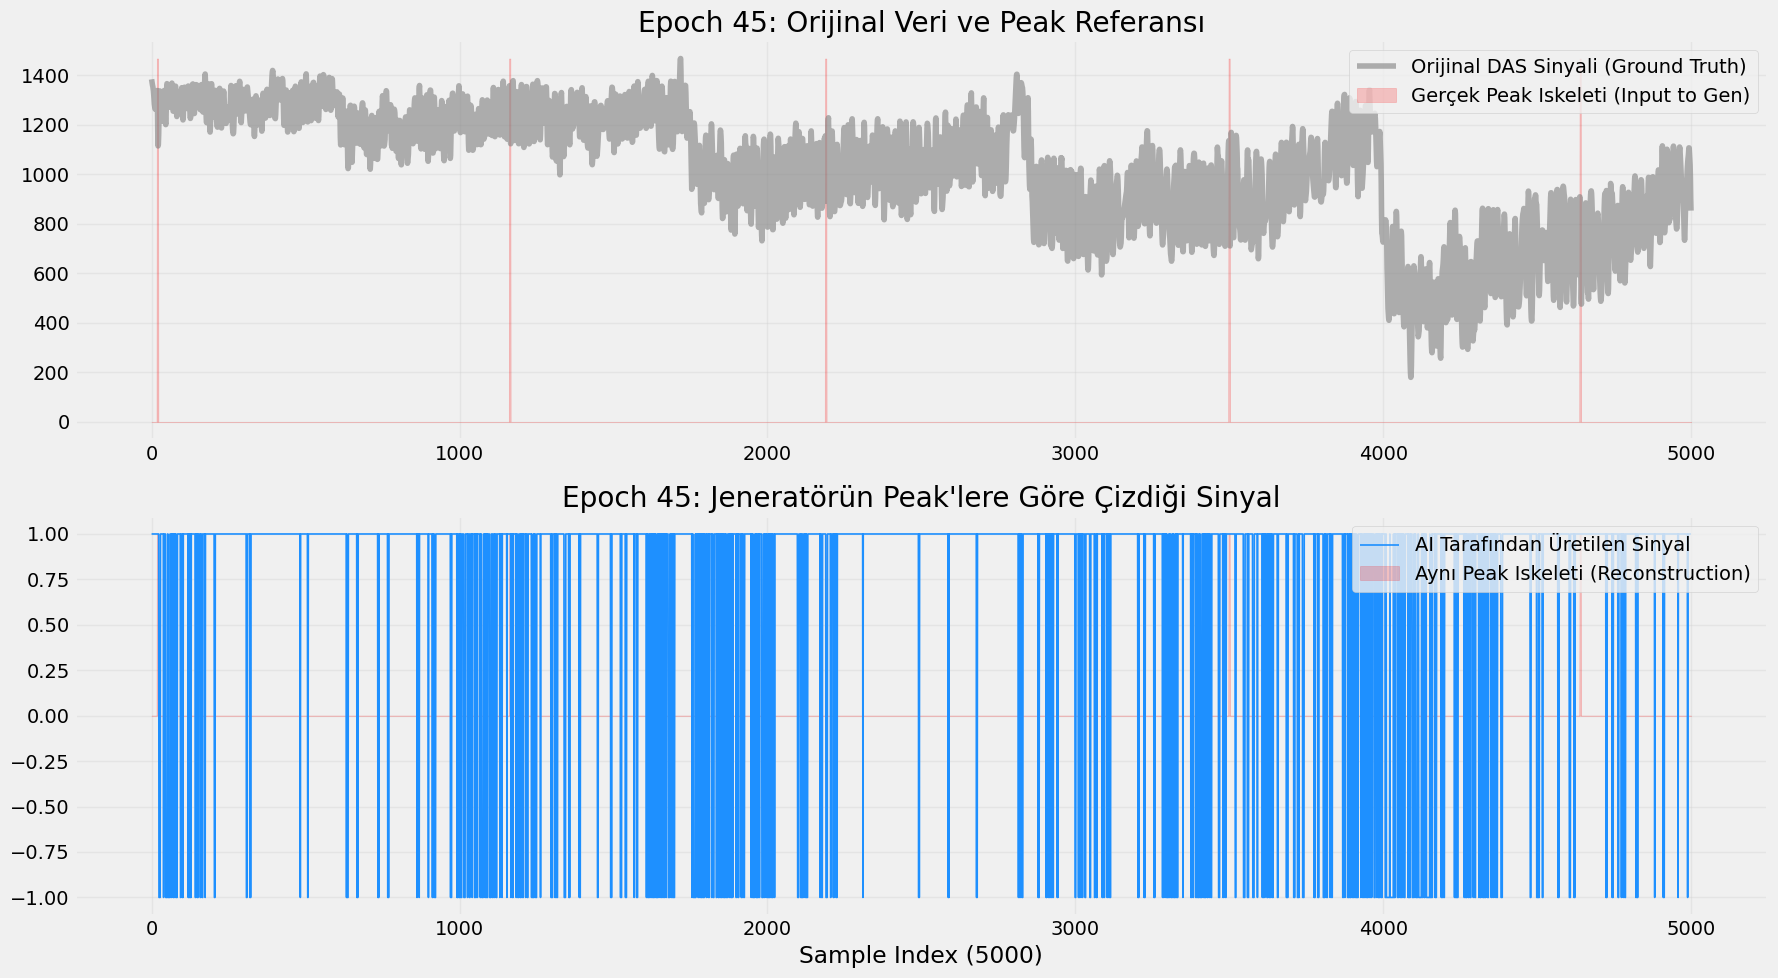

--- EPOCH 46 BAŞLADI ---
Epoch 46 | Step 366/367 | D_Loss: 1.3426 | G_Total: 1.29
Epoch 46 Özet | D_Loss: 1.3568 | G_Total: 1.26 | Rec: 1.29 | Cls: -0.00
--- EPOCH 47 BAŞLADI ---
Epoch 47 | Step 366/367 | D_Loss: 1.3545 | G_Total: 1.30
Epoch 47 Özet | D_Loss: 1.3519 | G_Total: 1.27 | Rec: 1.30 | Cls: 0.00
--- EPOCH 48 BAŞLADI ---
Epoch 48 | Step 366/367 | D_Loss: 1.3135 | G_Total: 1.27
Epoch 48 Özet | D_Loss: 1.3549 | G_Total: 1.26 | Rec: 1.27 | Cls: -0.00
--- EPOCH 49 BAŞLADI ---
Epoch 49 | Step 366/367 | D_Loss: 1.2911 | G_Total: 1.31
Epoch 49 Özet | D_Loss: 1.3596 | G_Total: 1.26 | Rec: 1.31 | Cls: 0.00
--- EPOCH 50 BAŞLADI ---
Epoch 50 | Step 366/367 | D_Loss: 1.2929 | G_Total: 1.26
Epoch 50 Özet | D_Loss: 1.3522 | G_Total: 1.26 | Rec: 1.26 | Cls: 0.00


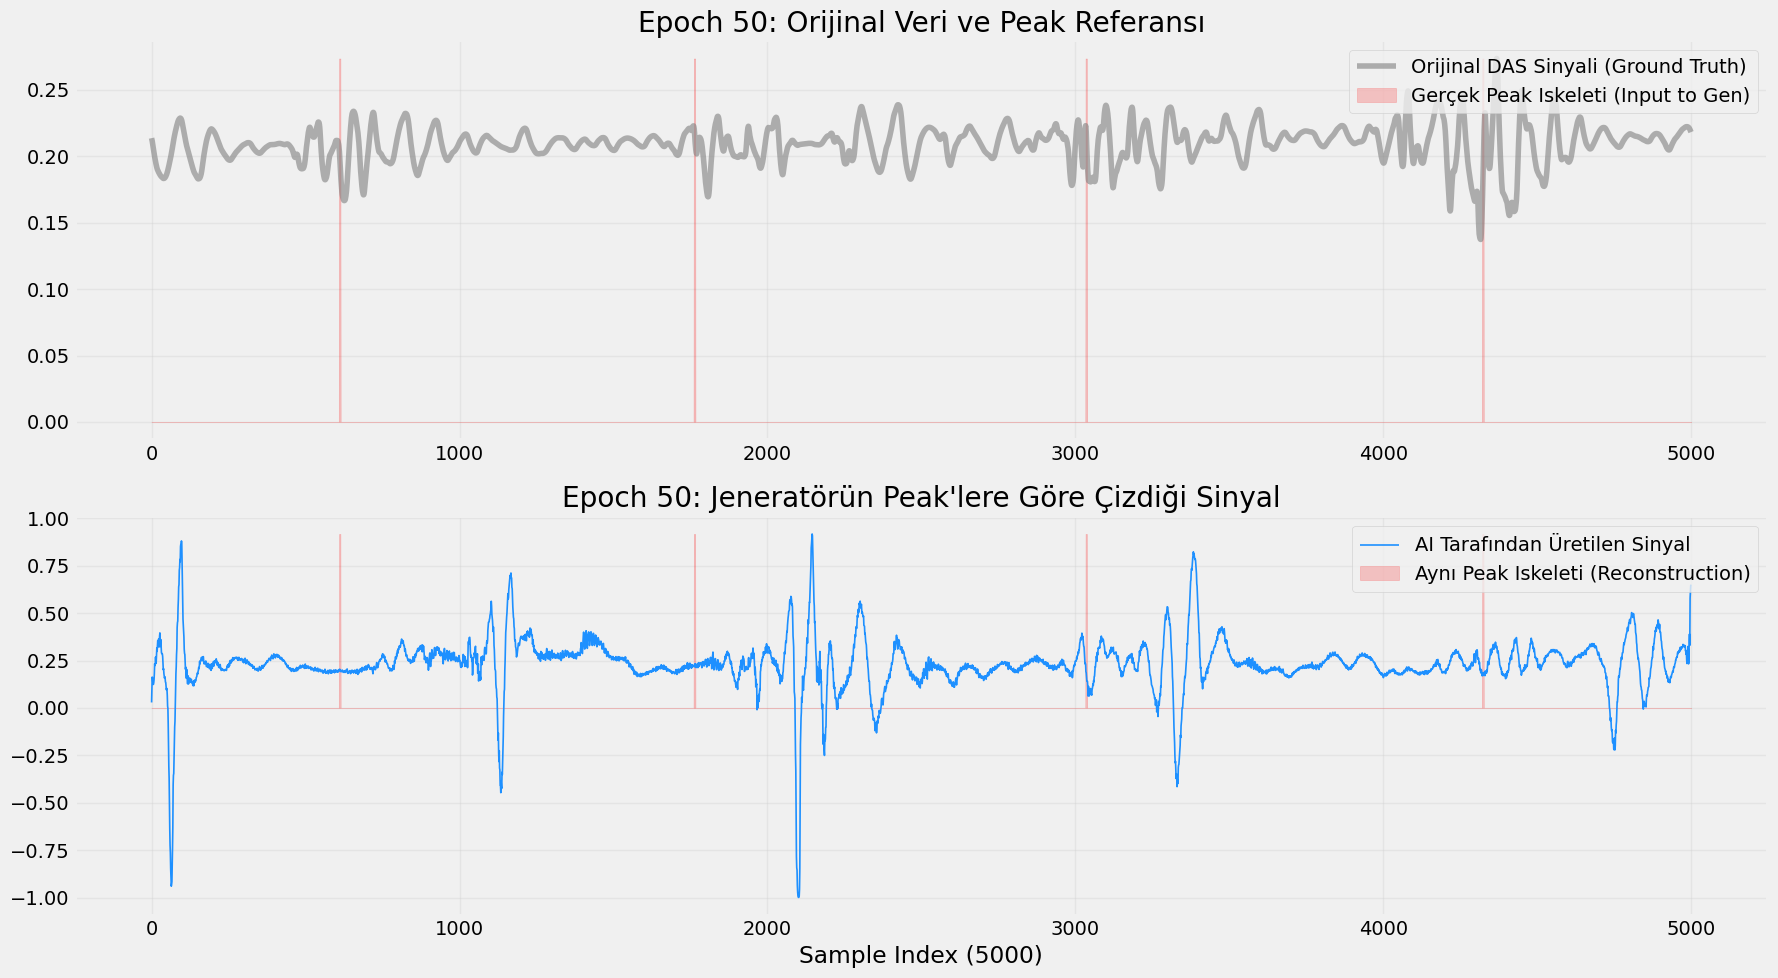

In [9]:
import time
import tensorflow as tf
EPOCHS = 50
for epoch in range(EPOCHS):
    start = time.time()
    
    epoch_d_loss = []
    epoch_g_loss = []
    
    total_steps = len(train_seq)
    print(f"--- EPOCH {epoch+1} BAŞLADI ---")
    for step in range(total_steps):
        # 1. Aşama: Veri çekiliyor mu?
        if step == 0 and epoch == 0:
            print("Veri setinden ilk batch çekiliyor...", flush=True)
            
        batch_data, _ = train_seq[step] 
        real_sigs = tf.convert_to_tensor(batch_data[:, :, 0:1], dtype=tf.float32)
        peaks = tf.convert_to_tensor(batch_data[:, :, 1:2], dtype=tf.float32)
        
        # 2. Aşama: Tracing uyarısı
        if step == 0 and epoch == 0:
            print("\n[BİLGİ] İlk step train_step'e gönderildi. TensorFlow grafiği derliyor (Tracing).")
            print("Bu işlem sistemine bağlı olarak 1-5 dakika sürebilir. Lütfen bekleyin...\n", flush=True)

        # Train step'i çalıştır
        d_l, g_l, l_rec, l_cls = train_step(real_sigs, peaks)
        
        epoch_d_loss.append(d_l)
        epoch_g_loss.append(g_l)
        
        # 3. Aşama: Çıktı basma (Her adımda anlık olarak)
        print(f"Epoch {epoch+1} | Step {step}/{total_steps} | D_Loss: {d_l:.4f} | G_Total: {g_l:.2f}", end='\r', flush=True)

    print(f"\nEpoch {epoch+1} Özet | D_Loss: {tf.reduce_mean(epoch_d_loss):.4f} | G_Total: {tf.reduce_mean(epoch_g_loss):.2f} | Rec: {l_rec:.2f} | Cls: {l_cls:.2f}", flush=True)
    
    if (epoch + 1) % 5 == 0:
        visualize_epoch_results(epoch, encoder, generator, train_seq)